# This Jupyter notebook file produces basic analysis related to neural signal correlation

In [1]:
import numpy as np
import scipy
import mat73
import sklearn
from utility_functions import *
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as Patches
from itertools import chain
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FactorAnalysis,PCA
from sklearn.linear_model import LinearRegression
import matplotlib.ticker as mticker
from contrastive import CPCA

plt.rcParams["axes.linewidth"] = 2
plt.rcParams["axes.edgecolor"] = 'k'
plt.rcParams['grid.alpha'] = 0

# Load the data and meta data
 Here we are only looking into the last 4s and last 1s aligned to the reward onset. So `data_type` should be "last4s"

In [2]:
data_type='last4s' # this could be 'trials', 'last4s', 'first4s','STA'.
monkey='C' # monkey should be one of 'C', 'J' or 'M'
CE=63 # channel name. NOTE: this is not the channel number or the channel index

# load the grid layout of the monkey
grid=get_grid(monkey)
# load the spike channel number
spike_channel=get_channel(monkey,CE)
# load the location of the CE on the grid
loc_x,loc_y=get_CE_loc(grid,spike_channel)
# load the shunted electrodes for this monkey. This is the python index
shunted_electrodes=load_shunted_electrodes(monkey,spike_channel)
# finally, load the raw data
raw_data=load_ONF_data(data_type, monkey, CE)
# We only need the "learned" files.
raw_data=raw_data[raw_data['file_types']=='learned']

Optional: Visualize the data table. This may take some time.

In [3]:
raw_data

,file_num,file_types,num_success,num_failed,success_rate,spike_rate,HGA,target_types,velocity,position,trial_types,date
4,08012013002,learned,45.0,74.0,0.37815126050420167,"[[[31.743000030517578, 32.89494323730469, 21.8...","[[[0.0, -1.2538522, -3.0115116, -1.4593784, -0...","[1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, ...","[[[0.0, 8.405367672425161, -4.838141611971598,...","[[[0.0, 14.374270804698018, 5.52249470640303, ...","[-1.0, 1.0, 1.0, 1.0, 1.0, 1.0, -1.0, -1.0, 1....",2013-08-01
9,08022013002,learned,49.0,41.0,0.5444444444444444,"[[[52.027099609375, 23.56011199951172, 38.1131...","[[[0.0, -2.7409751, -0.7458605, -0.15054448, -...","[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, ...","[[[0.0, 0.460790922673321, 4.913153661242769, ...","[[[0.0, 3.563215170489235, 8.926981418580347, ...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",2013-08-02
10,08022013003,learned,44.0,78.0,0.36065573770491804,"[[[37.7570915222168, 9.46125602722168, 11.2618...","[[[0.0, -2.177995, -3.6380808, -1.6661127, -0....","[1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, ...","[[[0.0, -6.76304610992148, -9.935647883871901,...","[[[0.0, 9.702787114111644, -5.54414504068969, ...","[1.0, 1.0, 1.0, 1.0, 1.0, -1.0, 1.0, 1.0, 1.0,...",2013-08-02
11,08022013005,learned,69.0,53.0,0.5655737704918032,"[[[40.242279052734375, 51.435028076171875, 33....","[[[0.0, -2.879361, -3.2876003, -2.1619277, -4....","[0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, ...","[[[0.0, -7.149004847652811, -3.818827394871178...","[[[0.0, 5.265844058757905, 6.790414535328919, ...","[1.0, -1.0, 1.0, 1.0, 1.0, 1.0, -1.0, 1.0, 1.0...",2013-08-02
12,08022013006,learned,64.0,62.0,0.5079365079365079,"[[[27.176071166992188, 21.41299057006836, 25.5...","[[[0.0, -2.470308, -5.5951633, -4.5585914, -1....","[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, ...","[[[0.0, -1.3224143150768874, 5.521622468173629...","[[[0.0, 5.369169623230652, 3.0665922763091675,...","[1.0, 1.0, 1.0, 1.0, -1.0, 1.0, -1.0, 1.0, 1.0...",2013-08-02
13,08022013007,learned,55.0,46.0,0.5445544554455446,"[[[39.79866409301758, 17.767541885375977, 46.3...","[[[0.0, -2.899141, -1.6385992, -2.6579359, -1....","[1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, ...","[[[0.0, 6.817514156412447, 2.8797445052528525,...","[[[0.0, -5.151466455438056, 4.740774115649596,...","[1.0, 1.0, 1.0, 1.0, 1.0, -1.0, 1.0, 1.0, 1.0,...",2013-08-02
14,08052013003,learned,53.0,21.0,0.7162162162162162,"[[[39.39125061035156, 19.2636661529541, 30.040...","[[[0.0, -2.3372345, -0.46217212, -3.2631755, -...","[0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, ...","[[[0.0, 1.5950260241078806, -4.602523502747203...","[[[0.0, 1.7369413551825428, 2.1505292630688246...","[1.0, 1.0, -1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0,...",2013-08-05
15,08052013004,learned,50.0,58.0,0.46296296296296297,"[[[26.318452835083008, 12.427763938903809, 3.2...","[[[0.0, -3.1120002, -0.09550953, -1.0181706, -...","[1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, ...","[[[0.0, -16.035158505388726, -7.05917073092267...","[[[0.0, 1.1482177338094721, 11.716224181218335...","[1.0, 1.0, 1.0, -1.0, 1.0, 1.0, 1.0, 1.0, 1.0,...",2013-08-05
17,08062013002,learned,67.0,57.0,0.5403225806451613,"[[[17.062484741210938, 4.8245930671691895, 19....","[[[0.0, -2.9626856, -2.9415834, -0.38071862, -...","[0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, ...","[[[0.0, -4.965144288043341, -5.45888552270665,...","[[[0.0, -3.5484509886955267, -0.87938975889640...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",2013-08-06


# Pre-process the spike rate and HGA data

1. include only the successful trials.
2. remove shunted channels
3. remove NAN and empty channels
4. remove channels with low firing rate

In [3]:
# Here we concatenate all the successful trials together for every file.
spike_rate_all = np.concatenate(raw_data['spike_rate'].to_list(),axis=-1).transpose(2,0,1) # num_electrodes x n_time_bin x n_trials
HGA_all = np.concatenate(raw_data['HGA'].to_list(),axis=-1).transpose(2,0,1) # num_electrodes x n_time_bin x n_trials

# We concatenate the trial type and target types
trial_types_all=np.concatenate(raw_data['trial_types'].to_list())
target_types_all=np.concatenate(raw_data['target_types'].to_list())

# We take out only the successful trials
spike_rate_successful=np.array([a for a,t in zip(spike_rate_all,trial_types_all) if t==1]).transpose(1,2,0)
HGA_successful=np.array([a for a,t in zip(HGA_all,trial_types_all) if t==1]).transpose(1,2,0)
trial_types=np.array([a for a,t in zip(target_types_all,trial_types_all) if t==1])

# concatenate the signals
spike_rate_flat=spike_rate_successful.reshape(spike_rate_successful.shape[0],-1)
HGA_flat=HGA_successful.reshape(HGA_successful.shape[0],-1)
n_trials=spike_rate_successful.shape[-1]
n_time=spike_rate_successful.shape[1]

# save the indices of the leftover electrodes
leftover_electrode_list=np.arange(0,spike_rate_flat.shape[0])

print(f"Before preprocessing, signals have the shape (chan x (time x n_trials)): {spike_rate_flat.shape}")
# remove shunted electrodes
spike_rate_flat=np.delete(spike_rate_flat,shunted_electrodes,axis=0)
HGA_flat=np.delete(HGA_flat,shunted_electrodes,axis=0)
leftover_electrode_list=np.delete(leftover_electrode_list,shunted_electrodes)
print(f"Removed the shunted electrodes, signals have the shape (chan x (time x n_trials)): {spike_rate_flat.shape}")

# check NAN electrodes in the data
has_nan_spike_rate=np.sum(np.isnan(spike_rate_flat),axis=1)
has_nan_HGA=np.sum(np.isnan(HGA_flat),axis=1)
has_nan=np.where(has_nan_spike_rate+has_nan_HGA)

# remove the electrodes with NAN values
spike_rate_flat=np.delete(spike_rate_flat,has_nan,axis=0)
HGA_flat=np.delete(HGA_flat,has_nan,axis=0)
leftover_electrode_list=np.delete(leftover_electrode_list,has_nan,axis=0)
print(f"Removed the electrodes with NAN values, signals have the shape (chan x (time x n_trials)): {spike_rate_flat.shape}")

# check the electrodes with constant low spike rate
low_spike_rate=5 # spikes/s
has_low_spike_rate=np.sum(spike_rate_flat,axis=1)<n_time*low_spike_rate/20 # 20 Hz
has_low_spike_rate=np.where(has_low_spike_rate==spike_rate_flat.shape[-1])

# remove the electrodes with low spike rate
spike_rate_flat=np.delete(spike_rate_flat,has_low_spike_rate,axis=0)
HGA_flat=np.delete(HGA_flat,has_low_spike_rate,axis=0)
leftover_electrode_list=np.delete(leftover_electrode_list,has_low_spike_rate)
print(f"Removed the electrodes with low spike rate, signals have the shape (chan x (time x n_trials)): {spike_rate_flat.shape}")

# get the number of clean electrodes
n_clean_electrodes=len(leftover_electrode_list)
CE_index=np.where(leftover_electrode_list==spike_channel-1)[0]


Before preprocessing, signals have the shape (chan x (time x n_trials)): (96, 36000)
Removed the shunted electrodes, signals have the shape (chan x (time x n_trials)): (71, 36000)
Removed the electrodes with NAN values, signals have the shape (chan x (time x n_trials)): (63, 36000)
Removed the electrodes with low spike rate, signals have the shape (chan x (time x n_trials)): (63, 36000)


In [4]:
spike_rate=spike_rate_flat.reshape(n_clean_electrodes,n_time,n_trials)
HGA=HGA_flat.reshape(n_clean_electrodes,n_time,n_trials)

spike_rate=spike_rate/(np.nanmax(np.nanmax(spike_rate, axis=1),axis=1)+1e-5)[:,None,None]# divided by the max of each electrode
spike_rate=spike_rate-np.nanmean(np.nanmean(spike_rate,axis=1),axis=1)[:,None,None]
HGA=HGA-np.nanmean(np.nanmean(HGA,axis=1),axis=1)[:,None,None]

# Plot the trial averages of spike rate and HGA during spike target control and HG target control

In [5]:
# calculate the trial averages
spike_rate_sp_tgt=spike_rate[:,:,trial_types==1].mean(-1)
spike_rate_hg_tgt=spike_rate[:,:,trial_types==0].mean(-1)

HGA_sp_tgt=HGA[:,:,trial_types==1].mean(-1)
HGA_hg_tgt=HGA[:,:,trial_types==0].mean(-1)
# mean center the trial averages

plot the trial averages. These plots are not Z-scored, thus the scale of the signals might be different from the paper, but the relationship between the electrodes is perserved.

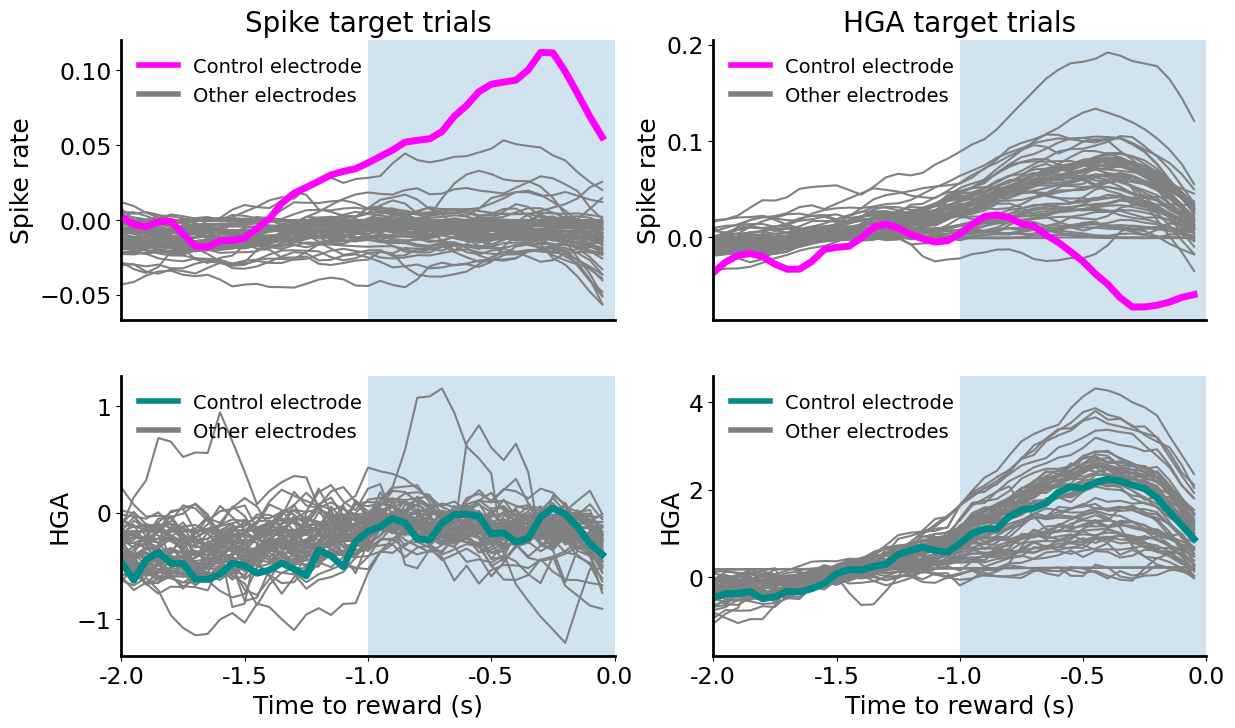

In [6]:
fig,ax=plt.subplots(2,2,figsize=(14,8))
# plot trial averages of spike rate
ax[0][0].plot(np.transpose(spike_rate_sp_tgt),color='grey')
ax[0][0].plot(np.squeeze(spike_rate_sp_tgt[CE_index]),color='magenta',lw=5)
ax[0][1].plot(np.transpose(spike_rate_hg_tgt),color='grey')
ax[0][1].plot(np.squeeze(spike_rate_hg_tgt[CE_index]),color='magenta',lw=5)
ax[0][0].set_xticks([])
ax[0][1].set_xticks([])

# plot trial averages of HGA
ax[1][0].plot(np.transpose(HGA_sp_tgt),color='grey')
ax[1][0].plot(np.squeeze(HGA_sp_tgt[CE_index]),color='darkcyan',lw=5)
ax[1][1].plot(np.transpose(HGA_hg_tgt),color='grey')
ax[1][1].plot(np.squeeze(HGA_hg_tgt[CE_index]),color='darkcyan',lw=5)
ax[1][0].set_xticks(np.linspace(0,80,9),[f"{a-4:0.1f}" for a in np.linspace(0,80*50/1000,9)],fontsize=18)
ax[1][1].set_xticks(np.linspace(0,80,9),[f"{a-4:0.1f}" for a in np.linspace(0,80*50/1000,9)],fontsize=18)

# beautification of the plots
ax[0][0].tick_params(labelsize=17)
ax[1][0].tick_params(labelsize=17)
ax[0][1].tick_params(labelsize=17)
ax[1][1].tick_params(labelsize=17)
ax[1][0].set_xlabel("Time to reward (s)",fontsize=18)
ax[1][1].set_xlabel("Time to reward (s)",fontsize=18)
ax[0][1].set_ylabel("Spike rate",fontsize=18)
ax[1][1].set_ylabel("HGA",fontsize=18)
ax[0][0].set_ylabel("Spike rate",fontsize=18)
ax[1][0].set_ylabel("HGA",fontsize=18)

ax[0][0].set_title("Spike target trials",fontsize=20)
ax[0][1].set_title("HGA target trials",fontsize=20)

# plot the legend
line1,=ax[0][0].plot([],color='magenta',lw=4)
line2,=ax[0][0].plot([],color='grey',lw=4)
ax[0][0].legend([line1,line2],['Control electrode','Other electrodes'],fontsize=14,frameon=False)

line1,=ax[1][0].plot([],color='darkcyan',lw=4)
line2,=ax[1][0].plot([],color='grey',lw=4)
ax[1][0].legend([line1,line2],['Control electrode','Other electrodes'],fontsize=14,frameon=False)

line1,=ax[0][1].plot([],color='magenta',lw=4)
line2,=ax[0][1].plot([],color='grey',lw=4)
ax[0][1].legend([line1,line2],['Control electrode','Other electrodes'],fontsize=14,frameon=False)

line1,=ax[1][1].plot([],color='darkcyan',lw=4)
line2,=ax[1][1].plot([],color='grey',lw=4)
ax[1][1].legend([line1,line2],['Control electrode','Other electrodes'],fontsize=14,frameon=False)

ax[0][0].spines['top'].set_visible(False)
ax[0][0].spines['right'].set_visible(False)
ax[0][0].grid(False)

ax[0][1].spines['top'].set_visible(False)
ax[0][1].spines['right'].set_visible(False)
ax[0][1].grid(False)

ax[1][0].spines['top'].set_visible(False)
ax[1][0].spines['right'].set_visible(False)
ax[1][0].grid(False)

ax[1][1].spines['top'].set_visible(False)
ax[1][1].spines['right'].set_visible(False)
ax[1][1].grid(False)

# indicate the last 1s
ax[0][0].axvspan(60,80,alpha=0.2)
ax[0][1].axvspan(60,80,alpha=0.2)
ax[1][0].axvspan(60,80,alpha=0.2)
ax[1][1].axvspan(60,80,alpha=0.2)

ax[0][0].set_xlim([40,80])
ax[0][1].set_xlim([40,80])
ax[1][0].set_xlim([40,80])
ax[1][1].set_xlim([40,80])

plt.show()

### Mean value of the last 1s of the trial average data.

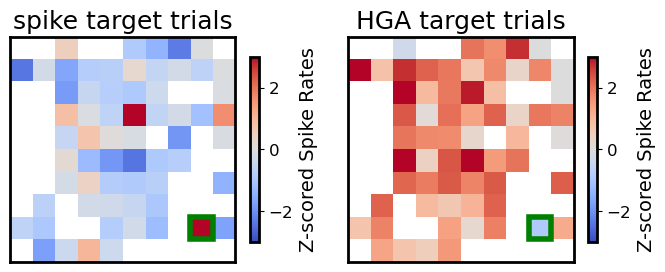

In [10]:
# this block plots the last 1 s of the mean firing rate on each electrode to demonstrate the firing pattern/HGA pattern are not spatially related to the control channel

mean_fr_sp_last_1s=np.mean(spike_rate_sp_tgt[:,60:80]/spike_rate_sp_tgt.std(),axis=1) # mean value of the last 1 s
mean_fr_hg_last_1s=np.mean(spike_rate_hg_tgt[:,60:80]/spike_rate_hg_tgt.std(),axis=1)


fr_range=[np.nanmin([mean_fr_hg_last_1s,mean_fr_sp_last_1s]),np.nanmax([mean_fr_hg_last_1s,mean_fr_sp_last_1s])]

fig,ax=plt.subplots(1,2,figsize=(8,3))
ftsz=18
im1=plot_on_grid(ax[0],leftover_electrode_list,grid,mean_fr_sp_last_1s,cmap=mpb.cm.coolwarm,loc=(loc_x,loc_y))
im2=plot_on_grid(ax[1],leftover_electrode_list,grid,mean_fr_hg_last_1s,cmap=mpb.cm.coolwarm,loc=(loc_x,loc_y))

im1.set_clim(-3,3)
im2.set_clim(-3,3)

cb1=plt.colorbar(im1,shrink=0.8)
cb2=plt.colorbar(im2,shrink=0.8)
cb1.ax.tick_params(labelsize=ftsz-6)
cb2.ax.tick_params(labelsize=ftsz-6)
cb1.set_label("Z-scored Spike Rates",fontsize=ftsz-4)
cb2.set_label("Z-scored Spike Rates",fontsize=ftsz-4)

ax[0].set_title("spike target trials",fontsize=ftsz)
ax[1].set_title("HGA target trials",fontsize=ftsz)

plt.show()

# This section processes the correlation between HGA and spike rate, as well as NAS distribution

C:\Users\Owner\miniconda3\envs\spike-highgamma\lib\site-packages\numpy\lib\function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\Owner\miniconda3\envs\spike-highgamma\lib\site-packages\numpy\lib\function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


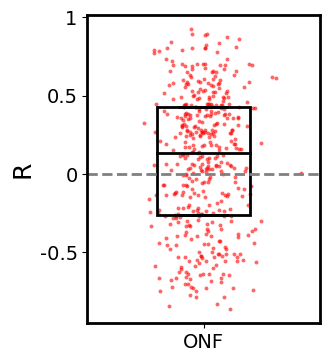

In [18]:
fig,ax=plt.subplots(1,1,figsize=(3,4))
x=np.random.normal(0,0.1,size=n_trials)
corr_ONF=np.diag(np.corrcoef(np.squeeze(spike_rate[CE_index,60:80]).T
                     ,np.squeeze(HGA[CE_index,60:80]).T)[:n_trials,n_trials:])
ax.scatter(x,corr_ONF,color='red',alpha=0.6, edgecolor=(0,0,0,0),linewidth=0,s=8)

clean_corr_ONF=corr_ONF[~np.isnan(corr_ONF)]
ax.boxplot(clean_corr_ONF,positions=[0],
           whis=0,widths=0.4,showfliers=False,patch_artist=True,
               boxprops=dict(facecolor=(0,0,0,0), linewidth=2),
               medianprops=dict(color='black', linewidth=2),
               whiskerprops=dict(linewidth=2),
                capprops=dict(linewidth=2),)

ax.axhline(0,linewidth=2,color='grey',linestyle='--')

ax.set_yticks([-0.5,0,0.5,1],[-0.5,0,0.5,1],fontsize=14)
ax.set_xticks(ticks=[0],labels=['ONF'],fontsize=14)
ax.set_ylabel("R",fontsize=18)
plt.show()

Calculate the NAS

In [31]:
CE_spike_rate_flat_last_1s=scipy.stats.zscore(spike_rate,axis=2)[CE_index, 60:80,:].flatten()
CE_HGA_flat_last_1s=scipy.stats.zscore(HGA,axis=2)[CE_index, 60:80,:].flatten()

NAS=np.squeeze(
    np.arctan2(
        CE_HGA_flat_last_1s,
        CE_spike_rate_flat_last_1s,
    )
) *180/np.pi


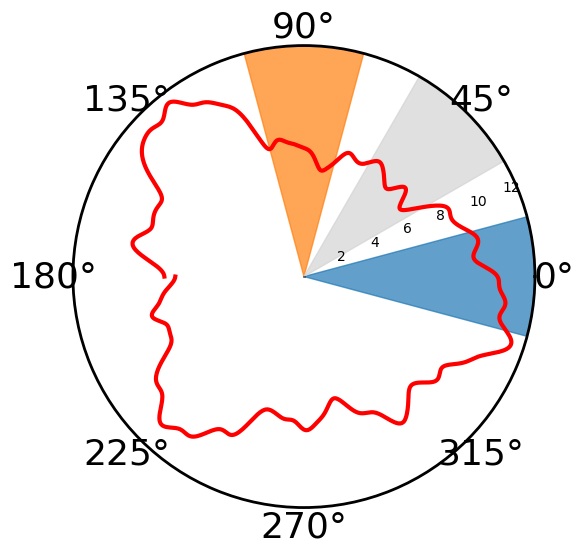

In [32]:
fig,ax=plt.subplots(figsize=(6,6),subplot_kw=dict(polar=True))

n, bins, patches = ax.hist(NAS, bins=1000, alpha=0.75)
ax.cla()
NAS_smooth=scipy.ndimage.gaussian_filter1d(n,10)
angles = np.linspace(-np.pi,np.pi,1000).tolist()

ax.vlines(0,0,0.006,colors='k',linewidth=2)
ax.vlines(np.pi/2,0,0.006,colors='k',linewidth=2)
ax.vlines(np.pi,0,0.006,colors='k',linewidth=2)
ax.vlines(3*np.pi/2,0,0.006,colors='k',linewidth=2)
ax.plot(angles,NAS_smooth,color='red',linewidth=3)

ax.axvspan(np.deg2rad(90-15),np.deg2rad(90+15),color='tab:Orange',alpha=0.7)
ax.axvspan(np.deg2rad(-15),np.deg2rad(15),color='tab:Blue',alpha=0.7)
ax.axvspan(np.deg2rad(30),np.deg2rad(60),color='lightgrey',alpha=0.7)


#ax.set_ylim(0,0.0052)
#ax.set_yticks(np.linspace(0,0.0052,3),['0','0.5','1'],fontsize=24)
for label in ax.get_xticklabels():
    label.set_fontsize(26)

plt.show()